In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')


df = pd.read_parquet('../data/processed/internacoes_psiquiatricas.parquet')

print(f"Registros: {len(df):,}")
print(f"Período: {df['DT_INTER'].min().date()} a {df['DT_INTER'].max().date()}")

Registros: 331,528
Período: 2008-01-01 a 2023-12-31


In [2]:
df = df[df['ANO'].between(2017, 2023)].copy()

def classificar_periodo(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2021:
        return 'Pandemia'
    else:
        return 'Pós-pandemia'

df['PERIODO'] = df['ANO'].apply(classificar_periodo)

print(df['PERIODO'].value_counts())
print(f"\nTotal de registros: {len(df):,}")

PERIODO
Pós-pandemia    151704
Pandemia        138585
Pré-pandemia     18209
Name: count, dtype: int64

Total de registros: 308,498


In [3]:
print(df[df['PERIODO'] == 'Pré-pandemia']['ANO'].value_counts())

ANO
2019    14005
2018     2623
2017     1581
Name: count, dtype: int64


In [2]:
dfs = []

for arquivo in arquivos_parquet:
    df_mes = pd.read_parquet(arquivo, engine='pyarrow')
    df_mes = df_mes[df_mes['DIAG_PRINC'].str.startswith('F', na=False)]
    dfs.append(df_mes)
    print(f"{arquivo.split('/')[-1]}: {len(df_mes):,} internações psiquiátricas")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal geral: {len(df_raw):,}")

RDSP2110.parquet: 6,744 internações psiquiátricas
RDSP1707.parquet: 8,075 internações psiquiátricas
RDSP1804.parquet: 8,216 internações psiquiátricas
RDSP2105.parquet: 5,782 internações psiquiátricas
RDSP2112.parquet: 6,877 internações psiquiátricas
RDSP1806.parquet: 7,837 internações psiquiátricas
RDSP2011.parquet: 6,659 internações psiquiátricas
RDSP2212.parquet: 7,141 internações psiquiátricas
RDSP1811.parquet: 7,591 internações psiquiátricas
RDSP2312.parquet: 7,739 internações psiquiátricas
RDSP2307.parquet: 7,515 internações psiquiátricas
RDSP2004.parquet: 6,447 internações psiquiátricas
RDSP2111.parquet: 7,093 internações psiquiátricas
RDSP2308.parquet: 7,889 internações psiquiátricas
RDSP2012.parquet: 6,662 internações psiquiátricas
RDSP1703.parquet: 9,069 internações psiquiátricas
RDSP1709.parquet: 8,532 internações psiquiátricas
RDSP1803.parquet: 8,238 internações psiquiátricas
RDSP2104.parquet: 5,916 internações psiquiátricas
RDSP2301.parquet: 7,506 internações psiquiátricas


In [3]:
colunas = [
    'ANO_CMPT', 'MES_CMPT', 'MUNIC_RES', 'NASC', 'SEXO', 'IDADE',
    'COD_IDADE', 'DIAG_PRINC', 'DIAG_SECUN', 'DT_INTER', 'DT_SAIDA',
    'DIAS_PERM', 'MORTE', 'VAL_TOT', 'RACA_COR', 'CNES', 'COMPLEX', 'FINANC'
]

df = df_raw[colunas].copy()

# tipos numéricos
df['DIAS_PERM'] = pd.to_numeric(df['DIAS_PERM'], errors='coerce')
df['VAL_TOT']   = pd.to_numeric(df['VAL_TOT'], errors='coerce')
df['IDADE']     = pd.to_numeric(df['IDADE'], errors='coerce')

# datas
df['DT_INTER'] = pd.to_datetime(df['DT_INTER'], format='%Y%m%d', errors='coerce')
df['DT_SAIDA'] = pd.to_datetime(df['DT_SAIDA'], format='%Y%m%d', errors='coerce')

# sexo e raça
df['SEXO']     = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})
df['RACA_COR'] = df['RACA_COR'].map({'01': 'Branca', '02': 'Preta', '03': 'Parda', '04': 'Amarela', '05': 'Indígena', '99': 'Ignorado'})

# ano e grupo diagnóstico
df['ANO'] = df['DT_INTER'].dt.year

def categorizar_cid(cid):
    grupos = {
        'F0': 'Transtornos orgânicos',
        'F1': 'Transtornos por uso de substâncias',
        'F2': 'Psicoses (esquizofrenia)',
        'F3': 'Transtornos de humor',
        'F4': 'Transtornos ansiosos',
        'F5': 'Síndromes comportamentais',
        'F6': 'Transtornos de personalidade',
        'F7': 'Deficiência intelectual',
        'F8': 'Transtornos do desenvolvimento',
        'F9': 'Transtornos da infância',
    }
    for prefixo, nome in grupos.items():
        if str(cid).startswith(prefixo):
            return nome
    return 'Outros'

df['GRUPO_DIAG'] = df['DIAG_PRINC'].apply(categorizar_cid)

# filtros
df = df[df['COD_IDADE'] == '4'].copy()
df = df.drop(columns=['COD_IDADE', 'INSTRU'] if 'INSTRU' in df.columns else ['COD_IDADE'])
df = df[df['ANO'].between(2017, 2023)].copy()

# período
def classificar_periodo(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2021:
        return 'Pandemia'
    else:
        return 'Pós-pandemia'

df['PERIODO'] = df['ANO'].apply(classificar_periodo)

print(f"Registros finais: {len(df):,}")
print(df['PERIODO'].value_counts())

Registros finais: 460,446
PERIODO
Pré-pandemia    170157
Pós-pandemia    151704
Pandemia        138585
Name: count, dtype: int64


In [4]:
df.to_parquet('../data/processed/internacoes_psiquiatricas.parquet', index=False)
print("Arquivo salvo!")
print(f"Shape final: {df.shape}")

Arquivo salvo!
Shape final: (460446, 20)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_parquet('../data/processed/internacoes_psiquiatricas.parquet')

print(f"Registros: {len(df):,}")
print(f"Período: {df['DT_INTER'].min().date()} a {df['DT_INTER'].max().date()}")

Registros: 460,446
Período: 2017-01-01 a 2023-12-31


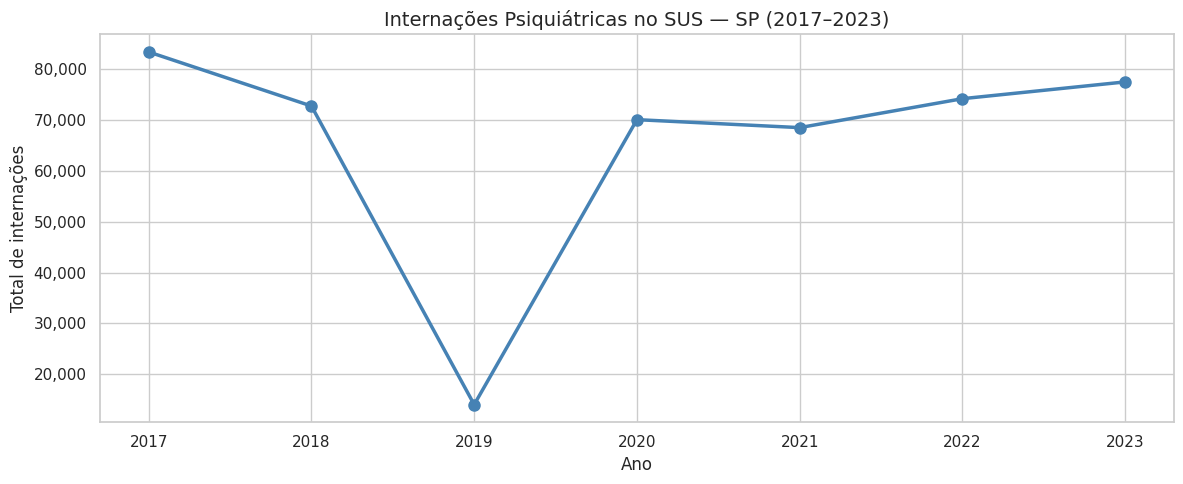

In [7]:
internacoes_ano = df.groupby('ANO').size().reset_index(name='total')

fig, ax = plt.subplots()

ax.plot(internacoes_ano['ANO'], internacoes_ano['total'], 
        marker='o', linewidth=2.5, markersize=8, color='steelblue')

ax.set_title('Internações Psiquiátricas no SUS — SP (2017–2023)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Total de internações')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/01_evolucao_anual.png', dpi=150)
plt.show()

In [8]:
print(df[df['ANO'] == 2019]['DT_INTER'].dt.month.value_counts().sort_index())

DT_INTER
1     1288
2      507
3      415
4      187
5      210
6      159
7      652
8     3052
9      335
10    1193
11    1589
12    4418
Name: count, dtype: int64
